In [38]:
import os

from pathlib import Path
from typing import TypedDict, List, Annotated, Literal, Optional, Dict, Any
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

from langchain_openrouter import ChatOpenRouter
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.vectorstores import InMemoryVectorStore

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters  import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

from langchain_core.prompts import ChatPromptTemplate
import operator
from langchain_core.tools import tool
from dotenv import load_dotenv

import tempfile
import urllib.request
from langchain_core.documents import Document
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt
from langgraph.types import Command

In [39]:
# states
class PaperSummary(BaseModel):
    title: str=Field(...,description="The official title of the paper")
    problem_domain: str=Field(..., description="The specific problem being solved (e.g., Tabular Data Classification, Time Series Forecasting).")
    authors: List[str]=Field(..., description="List of the paper's authors.")
    abstract: str=Field(description="A brief summary of the paper")
    publication_year: Optional[int]=Field(default=None, description="The year the paper was published.")
    code_repository_url: Optional[str]=Field(
        default=None, 
        description="URL to the GitHub or code repository if provided in the text."
    )
    
    novel_architecture_proposed: Optional[str]=Field(
        default=None,
        description="Name of the new model proposed (e.g., FT-Transformer) i.e the originality of this paper. Return null if it's a survey or comparative study."
    )
    models_evaluated: List[str]=Field(..., description="List of all models tested or compared (e.g., XGBoost, ResNet, TabNet). DO NOT include optimizers (e.g., Adam), regularization techniques (e.g., Dropout), or datasets.")
    datasets_used: List[str]=Field(..., description="List of specific datasets used for benchmarking (e.g., Adult, Higgs, California Housing).")
    
    evaluation_metrics: List[str]=Field(..., description="Metrics used to measure performance (e.g., RMSE, Accuracy, F1-score).")
    
    main_conclusion: str=Field(..., description="The primary finding or takeaway of the research.")
    key_limitations: Optional[str]=Field(
        default=None, 
        description="Any stated limitations, failures, or disadvantages mentioned by the authors."
    )
    research_gap_addressed: Optional[str]=Field(
        default=None, 
        description="The specific flaw or missing piece in existing literature this paper attempts to solve (e.g., 'Previous time-series forecasting models fail to capture long-term dependencies.')."
    )
    future_research_gaps: Optional[str]=Field(
        default=None, 
        description="Unsolved problems, open questions, or future work explicitly mentioned by the authors at the end of the paper."
    )
    key_citations: List[str]=Field(
        description="A list of exact quotes and claims mapped to their source page, e.g., 'FT-Transformer outperforms ResNet on categorical data (Page 6)'.")

class ResearchGraphState(TypedDict):
    pdf_paths: Optional[List[str]]
    candidate_papers: List[Any]
    selected_papers: List[Any]
    user_query: str

    research_plan: List[str]
    current_step: str
    search_queries: List[str]

    extracted_summaries: List[PaperSummary]
    errors: List[str]
    retry_count: int

    final_comparison: Optional[str]


In [40]:
llm=ChatOpenRouter(
    model="cohere/north-mini-code:free",
    temperature=0
)

In [41]:
from langchain_openai import OpenAIEmbeddings
import os
load_dotenv()

embeddings=OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=os.getenv("OPENROUTER_API_KEY"), # type: ignore
    base_url="https://openrouter.ai/api/v1",
)

In [42]:
class Plan(BaseModel):
    steps: List[str]=Field( ..., description="A list of step-by-step subtasks required to resolve the user query."
    )

In [43]:
# This node generates plan from the user query

# def planner(state: ResearchGraphState) -> dict:
#     structured_llm=llm.with_structured_output(Plan)
#     plan=structured_llm.invoke([
#         SystemMessage(content=(
#     "You are an expert research planner. Breakdown the user query into smaller "
#     "subtasks which to be performed in a step-by-step fashion.\n\n"
#     "CRITICAL INSTRUCTION: You must respond ONLY with valid JSON matching the exact schema requested. "
#     "Do NOT wrap the JSON in markdown code blocks (e.g., ```json). "
#     "Do NOT include any conversational text, greetings, or explanations before or after the JSON. "
#     "Your entire response must start with { and end with }.\n\n"
#     "Example Query: 'Compare how these papers handle missing data.'\n"
#     "Example Output:\n"
#     "{\n"
#     "  \"steps\": [\n"
#     "    \"1. Extract datasets and models from all papers.\",\n"
#     "    \"2. Search specifically for methodology chunks mentioning 'missing data' or 'imputation'.\",\n"
#     "    \"3. Compare the imputation strategies.\"\n"
#     "  ]\n"
#     "}"
# )),
#         HumanMessage(content=f"Query: {state['user_query']}")
#     ])
#     if not plan:
#         print("Plan can't generated.")
#         return {'research_plan':""}
#     return {'research_plan':plan.steps}


from langchain_core.output_parsers import JsonOutputParser

def planner(state: ResearchGraphState) -> dict:
    parser=JsonOutputParser(pydantic_object=Plan)
    
    # We append the formatting instructions directly to the system prompt
    prompt=ChatPromptTemplate.from_messages([
        ("system", "You are an expert research planner. Breakdown the query into step-by-step subtasks.\n{format_instructions}"),
        ("human", "Query: {user_query}")
    ])
    
    # Pipe it into the parser instead of using with_structured_output
    chain=prompt | llm | parser
    
    plan_dict=chain.invoke({
        "user_query": state['user_query'],
        "format_instructions": parser.get_format_instructions()
    })
    
    # The parser returns a dictionary, so we access the key directly
    return {'research_plan': plan_dict['steps']}

In [44]:
import requests
import arxiv
import time

load_dotenv()
SEMANTIC_SCHOLAR_API_KEY=os.environ.get("SEMANTIC_SCHOLAR_API_KEY", "")

def fetch_candidate_papers(state: ResearchGraphState) -> dict:
    query=state['user_query']
    candidates=[]
    print("Querying arXiv...")
    try:
        client=arxiv.Client()
        search=arxiv.Search(
            query=query,
            max_results=7,
            sort_by=arxiv.SortCriterion.Relevance
        )
        for result in client.results(search):
            candidates.append({
                "title":result.title.replace("\n"," "),
                "abstract":result.summary.replace('\n',' '),
                "source":"arXiv",
                "url":result.pdf_url
            })
    except Exception as e:
        print(f"arXiv fetch failed: {e}")


    print("Querying Semantic Scholar...")
    url="https://api.semanticscholar.org/graph/v1/paper/search"
    params={
        "query": query,
        "limit": 8, 
        "fields": "title,abstract,url,year,openAccessPdf"
    }
    
    headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
    
    if SEMANTIC_SCHOLAR_API_KEY:
        headers['x-api-key']=SEMANTIC_SCHOLAR_API_KEY

    max_retries=3
    for attempt in range(max_retries):
        try:
            response=requests.get(url, params=params, headers=headers, timeout=10)
            
            if response.status_code == 200:
                data=response.json()
                if "data" in data:
                    for paper in data["data"]:
                        if paper.get("abstract"):
                            open_pdf=paper.get("openAccessPdf")
                            pdf_link=open_pdf.get("url") if open_pdf else paper.get("url", "")
                            
                            candidates.append({
                                "title": paper.get("title", "Unknown Title"),
                                "abstract": paper.get("abstract", ""),
                                "source": "Semantic Scholar",
                                "url": pdf_link
                            })
                break 
                
            elif response.status_code == 429:
                wait_time=2 ** attempt 
                print(f"Semantic Scholar rate limit hit (429). Retrying in {wait_time}s...")
                time.sleep(wait_time)
                
            else:
                print(f"Semantic Scholar returned status code {response.status_code}")
                break  
                
        except Exception as e:
            print(f"Semantic Scholar fetch failed on attempt {attempt+1}: {e}")
            time.sleep(2)

    unique_candidates=[]
    seen_titles=set()
    
    for paper in candidates:
        title_key=paper["title"].strip().lower()
        if title_key not in seen_titles:
            seen_titles.add(title_key)
            unique_candidates.append(paper)

    print(f"Successfully fetched {len(unique_candidates)} unique candidate papers.")
    return {"candidate_papers": unique_candidates}


In [45]:
class PaperSelection(BaseModel):
    selected_indices: List[int]=Field(
        ..., 
        description="List of 0-based integer indices corresponding to the 2 to 3 most relevant papers."
    )
    reasoning: str=Field(
        ..., 
        description="A concise technical justification for why these specific papers were chosen."
    )

In [46]:
def select_paper(state: ResearchGraphState) -> dict:
    candidates=state.get("candidate_papers", [])
    query=state.get("user_query", "")
    
    if not candidates:
        print("No candidate papers found to filter.")
        return {"selected_papers": []}
    
    formatted_candidates=""
    for idx, paper in enumerate(candidates):
        formatted_candidates += (
            f"Paper Index [{idx}]:\n"
            f"Title: {paper['title']}\n"
            f"Source: {paper['source']}\n"
            f"Abstract: {paper['abstract']}\n"
            f"{'-'*50}\n"
        )
    
    structured_llm=llm.with_structured_output(PaperSelection)
    
    prompt=ChatPromptTemplate.from_messages([
        ("system", (
            "You are a senior research librarian performing literature triage.\n"
            "Evaluate the provided candidate papers against the user query.\n\n"
            "CRITERIA:\n"
            "1. Select the top 2 to 3 most relevant papers that directly address the core methodological or comparative query.\n"
            "2. Prioritize empirical, benchmark, or structural survey papers over tangential studies.\n"
            "3. Return ONLY valid 0-based indices matching the Paper Index numbers."
        )),
        ("human", "User Query: {user_query}\n\nCandidate Papers:\n{candidates_list}\n\nSelect the best papers.")
    ])
    
    chain=prompt | structured_llm
    
    print(f"--- EVALUATING {len(candidates)} ABSTRACTS WITH LLM ---")
    selection=chain.invoke({
        "user_query": query,
        "candidates_list": formatted_candidates
    })
    
    selected_papers=[]
    reasoning="No reasoning provided."
    
    if selection and selection.selected_indices:
        reasoning=selection.reasoning
        for idx in selection.selected_indices:
            if 0 <= idx < len(candidates):
                selected_papers.append(candidates[idx])

    else:
        print("LLM failed to return structured selection. Falling back to the top 3 candidates.")
        reasoning="Fallback triggered due to LLM parsing failure."
        selected_papers=candidates[:3]
                
    print(f"Selected {len(selected_papers)} papers for full analysis:")
    for p in selected_papers:
        print(f"   • [{p['source']}] {p['title']}")
    print(f"-> Reasoning: {reasoning}\n")

    # hitl
    decision=interrupt({
        "message": "Review and confirm papers selected for full RAG analysis.",
        "proposed_papers": selected_papers,
        "reasoning": reasoning,
        "all_candidates": candidates
    })

    final_selected=decision.get("approved_papers", selected_papers)
    
    approved_titles={p['title'] for p in final_selected}
    rejected_papers=[p for p in selected_papers if p['title'] not in approved_titles]
    
    if rejected_papers:
        print(f"Human rejected {len(rejected_papers)} proposed paper(s):")
        for p in rejected_papers:
            print(f"    [{p['source']}] {p['title']}")
        print()

    if final_selected:
        print(f"Human confirmed {len(final_selected)} paper(s) for full extraction:")
        for p in final_selected:
            print(f"   • [{p['source']}] {p['title']}")
    else:
        print("Human rejected all proposed papers. Proceeding with 0 papers.")
        
    print()
        
    return {"selected_papers": final_selected}

In [47]:
def critic(state: ResearchGraphState) -> dict: # type: ignore
    summaries=state.get("extracted_summaries", [])
    errors=[]

    if not summaries:
        return {
            "errors": ["Extraction failed: No paper summaries were generated."],
            "retry_count": state.get('retry_count', 0)
        }

    invalid_strings=["", "n/a", "not specified", "none mentioned", "none", "not provided", "unknown"]

    for summary in summaries:
        if not summary:
            continue
            
        missing=[]

        models=getattr(summary, 'models_evaluated', []) or []
        datasets=getattr(summary, 'datasets_used', []) or []
        metrics=getattr(summary, 'evaluation_metrics', []) or []
        authors=getattr(summary, 'authors', []) or []

        if not models:
            missing.append("models_evaluated")
        if not datasets:
            missing.append("datasets_used")
        if not metrics:
            missing.append("evaluation_metrics")
        if not authors:
            missing.append("authors")

        title=getattr(summary, 'title', "") or ""
        if not title or title.strip().lower() in invalid_strings:
            missing.append("title")
            
        main_conclusion=getattr(summary, 'main_conclusion', "") or ""
        if not main_conclusion or main_conclusion.strip().lower() in invalid_strings:
            missing.append("main_conclusion")
            
        problem_domain=getattr(summary, 'problem_domain', "") or ""
        if not problem_domain or problem_domain.strip().lower() in invalid_strings:
            missing.append("problem_domain")

        if missing:
            paper_name=title.strip() if title.strip() else "Unknown Paper"
            errors.append(f"Missing {', '.join(missing)} in paper: {paper_name}")

    retries=state.get('retry_count', 0)
    
    return {
        "errors": errors,
        "retry_count": retries
    }

In [48]:
class SearchQuery(BaseModel):
    queries: List[str]=Field(...,description="A list of 2 to 3 highly specific vector search queries to find the missing information.")

In [49]:
# This node rewrites query for missing informations

def rewrite_query(state: ResearchGraphState) -> dict:
    errors=state.get("errors", [])
    error_string="\n".join(errors)
    structured_llm=llm.with_structured_output(SearchQuery)
    
    retries=state.get('retry_count', 0)
    print(f"--- REWRITING QUERIES (Attempt {retries + 1}) ---")
    
    fallback_queries=[
        "models evaluated, baseline architectures, methodology",
        "datasets used, experimental setup, benchmarks",
        "evaluation metrics, results, main conclusions"
    ]

    try:
        result=structured_llm.invoke([
            SystemMessage(content=("You are an AI assistant helping to fix incomplete document extractions. "
                "The previous extraction missed critical fields in a research paper. "
                "Look at the errors provided and generate highly specific search queries to find the missing information. "
                "For example, if 'datasets_used' is missing, generate a query like: 'we evaluate our model on the following datasets benchmark'.")),
            HumanMessage(content=f"Here are the missing fields from the previous extraction:\n{error_string}\n\nGenerate the new search queries.")    
        ])
        
        if result is None or not hasattr(result, 'queries'):
            print("LLM failed to return structured queries. Using fallbacks.")
            new_queries=fallback_queries
        else:
            new_queries=result.queries
            
    except Exception as e:
        print(f"Error during query generation: {e}. Using fallbacks.")
        new_queries=fallback_queries
        
    print(f"New Queries: {new_queries}")
    
    return {
        "search_queries": new_queries,
        "retry_count": retries + 1
    }

In [50]:
def path_after_planner(state: ResearchGraphState) -> str:
    pdf_paths=state.get("pdf_paths", [])
    
    if pdf_paths and len(pdf_paths) > 0:
        print("Detected local PDFs. Routing directly to extraction.")
        return "extract_paper_rag"
    
    print("No local PDFs provided. Routing to autonomous internet search.")
    return "fetch_candidate_papers"

In [51]:
# This node finds all the info regarding a research ppr

def extract_paper_rag(state: ResearchGraphState) -> dict: # type: ignore
    summaries=[]
    local_pdfs=state.get("pdf_paths", [])
    selected_papers=state.get("selected_papers", [])

    def perform_rag_extraction(docs_to_process, paper_title):
        splitter=RecursiveCharacterTextSplitter(chunk_size=1200, chunk_overlap=200)
        chunks=splitter.split_documents(docs_to_process)
        
        vector_store=InMemoryVectorStore.from_documents(chunks, embeddings)
        retriever=vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

        queries_to_run=state.get('search_queries', [])
        if not queries_to_run:
            queries_to_run=[
                "title, authors, abstract, introduction, problem domain, research gap",
                "models evaluated, novel architecture proposed, methodology",
                "datasets used, evaluation metrics, main conclusions, limitations"
            ]

        retrieved_chunks=[]
        for q in queries_to_run:
            retrieved_chunks.extend(retriever.invoke(q))

        formatted_chunks=[]
        for c in retrieved_chunks:
            page_num=c.metadata.get('page',0)+1
            formatted_chunks.append(f"--- Page {page_num} ---\n{c.page_content}")

        context="\n\n".join(list(set(formatted_chunks)))

        structured_llm=llm.with_structured_output(PaperSummary)

        prompt=ChatPromptTemplate.from_messages([
            ("system", """You are an expert AI researcher analyzing scientific literature. 
STRICT RULES:
1. ONLY extract information explicitly stated in the provided text.
2. DO NOT hallucinate fields.
3. If a field is not mentioned, leave it empty or null.
4. CITATION REQUIREMENT: For every model, dataset, and metric extracted, you MUST append its exact page number in parentheses based on the '--- Page X ---' headers. (e.g., 'XGBoost (Page 4)').
5. Populate the 'key_citations' field with 2-3 major claims and their exact page numbers."""),
            ("human", "Here is the text from the research paper:\n\n{context}\n\nExtract the requested information with page citations.")
        ])
        
        chain=prompt | structured_llm
        try:
            result=chain.invoke({'context': context})
            if result is None:
                print(f"LLM returned None for {paper_title}. Using fallback schema.")
                result=PaperSummary(title=paper_title, authors=[], abstract="Extraction failed.", problem_domain="", models_evaluated=[], datasets_used=[], evaluation_metrics=[], main_conclusion="", key_citations=[])
            return result
        except Exception as e:
            print(f"Error during LLM structured output extraction: {e}")
            return PaperSummary(title=paper_title, authors=[], abstract="Extraction failed.", problem_domain="", models_evaluated=[], datasets_used=[], evaluation_metrics=[], main_conclusion="", key_citations=[])

    # PATH A: Process Local PDFs
    if local_pdfs:
        for pdf_path in local_pdfs:
            print(f"--- Extracting local paper: {pdf_path} ---")
            loader=PyPDFLoader(pdf_path)
            docs=loader.load()
            summary=perform_rag_extraction(docs, pdf_path)
            summaries.append(summary)

    # PATH B: Process Internet-Fetched Papers
    elif selected_papers:        
        for paper in selected_papers:
            pdf_url=paper.get("url", "")
            title=paper.get("title", "Unknown Title")
            print(f"--- Extracting fetched paper: {title} ---")
            
            docs=[]
            if pdf_url:
                if "arxiv.org/abs/" in pdf_url:
                    pdf_url=pdf_url.replace("/abs/", "/pdf/") + ".pdf"
                
                tmp_file_path=None
                try:
                    headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
                    response=requests.get(pdf_url, headers=headers, stream=True, timeout=15)
                    response.raise_for_status() 

                    content_type=response.headers.get("Content-Type", "").lower()
                    first_bytes=response.content[:10].lower()
                    
                    if "text/html" in content_type or first_bytes.startswith(b"<!doc") or first_bytes.startswith(b"<html"):
                        raise ValueError("URL returned an HTML web page instead of a raw PDF file.")

                    with tempfile.NamedTemporaryFile(suffix=".pdf", delete=False) as tmp_file:
                        tmp_file.write(response.content)
                        tmp_file_path=tmp_file.name
                    
                    loader=PyPDFLoader(tmp_file_path)
                    docs=loader.load()
                        
                except Exception as e:
                    print(f"Could not parse PDF from {pdf_url}: {e}")

                finally:
                    if tmp_file_path and os.path.exists(tmp_file_path):
                        try:
                            os.remove(tmp_file_path)
                        except Exception as cleanup_err:
                            print(f"Could not remove temp file: {cleanup_err}")
            
            if not docs:
                print(f"Falling back to abstract context for: {title}")
                docs=[Document(page_content=f"Title: {title}\nAbstract: {paper.get('abstract', '')}")]

            summary=perform_rag_extraction(docs, title)
            if summary:
                summaries.append(summary)
            
    return {"extracted_summaries": summaries}

In [52]:
def comparison(state: ResearchGraphState) -> dict:
    summaries=state.get('extracted_summaries',[])
    query=state.get('user_query',"")

    if not summaries:
        return {"final_comparison": "No papers were successfully extracted to compare."}
    
    formatted_summaries=""
    for idx, s in enumerate(summaries):
        title=getattr(s, 'title', 'Unknown Title')
        models=", ".join(getattr(s, 'models_evaluated', []))
        datasets=", ".join(getattr(s, 'datasets_used', []))
        metrics=", ".join(getattr(s, 'evaluation_metrics', []))
        conclusion=getattr(s, 'main_conclusion', '')
        
        formatted_summaries += f"### Paper {idx + 1}: {title}\n"
        formatted_summaries += f"- **Models Evaluated:** {models}\n"
        formatted_summaries += f"- **Datasets Used:** {datasets}\n"
        formatted_summaries += f"- **Evaluation Metrics:** {metrics}\n"
        formatted_summaries += f"- **Main Conclusion:** {conclusion}\n"
        
        citations=getattr(s, 'key_citations', [])
        if citations:
            formatted_summaries += "- **Key Citations:**\n"
            for cite in citations:
                formatted_summaries += f"  * {cite}\n"
                
        formatted_summaries += "-" * 50 + "\n\n"

    prompt=ChatPromptTemplate.from_messages([
        ("system", """You are a Principal AI Researcher writing a final synthesis report.
Your goal is to compare the provided research papers based on the user's query.

FORMATTING RULES:
1. Use clean Markdown (## headers, tables, bullet points).
2. PRESERVE CITATIONS: The provided text includes page numbers in parentheses (e.g., 'XGBoost (Page 4)'). You MUST preserve these exact page references in your tables and paragraphs. Do not remove them.
3. Include a 'Comparison Matrix' table mapping Models vs. Datasets vs. Metrics (with their page citations).
4. Include a dedicated 'Key Claims & Evidence' section that highlights the most important findings using the provided Key Citations.
5. End with a bottom-line synthesis or recommendation."""),
        ("human", "User Query: {query}\n\nExtracted Paper Data:\n{summaries}\n\nGenerate the comparative synthesis report.")
    ])

    chain=prompt | llm 
    
    print("--- GENERATING FINAL COMPARATIVE SYNTHESIS ---")
    
    try:
        response=chain.invoke({
            "query": query, 
            "summaries": formatted_summaries
        })
        final_text=response.content if hasattr(response, 'content') else str(response)
        return {"final_comparison": final_text}
        
    except Exception as e:
        print(f"Error during final comparison generation: {e}")
        return {"final_comparison": f"Failed to generate comparison due to error: {e}"}

In [53]:
# This is to decide which path to take after the critic node

def path_after_critic(state: ResearchGraphState):
    errors=state.get("errors",[])
    retries=state.get("retry_count",0)
    MAX_RETRIES=3

    if errors and retries<MAX_RETRIES:
        print(f"Critic found errors: {errors}. Routing to retry...")
        return "rewrite_query"
    
    if errors and retries>=MAX_RETRIES:
        print("Max retries reached. Proceeding to comparison with limited data.")
        return "compare"
    
    print("Critic approved the extraction. Proceeding to comparison.")
    return "compare"


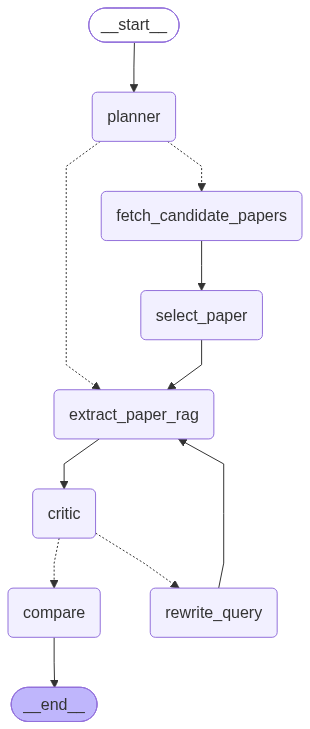

In [54]:
g=StateGraph(ResearchGraphState)

g.add_node("planner",planner)
g.add_node("fetch_candidate_papers",fetch_candidate_papers)
g.add_node("select_paper",select_paper)
g.add_node("extract_paper_rag",extract_paper_rag)
g.add_node("critic",critic)
g.add_node("rewrite_query",rewrite_query)
g.add_node("compare",comparison)

g.add_edge(START,"planner")
g.add_conditional_edges(
    "planner",
    path_after_planner,
    {
        "extract_paper_rag":"extract_paper_rag",
        "fetch_candidate_papers":"fetch_candidate_papers"
    }   
)
g.add_edge("fetch_candidate_papers","select_paper")
g.add_edge("select_paper","extract_paper_rag")
g.add_edge("extract_paper_rag","critic")
g.add_conditional_edges(
    "critic",
    path_after_critic,
    {
        "rewrite_query": "rewrite_query", # If function returns "rewrite_query", go to node "rewrite_query"
        "compare": "compare"              # If function returns "compare", go to node "compare"
    }
    )
g.add_edge("rewrite_query","extract_paper_rag")
g.add_edge("compare",END)

checkpointer=MemorySaver()

graph=g.compile(checkpointer=checkpointer)
graph


In [55]:
initial_state={
    "user_query": "Compare deep learning architectures like FT-Transformer and TabNet against traditional tree-based models like XGBoost for tabular data classification.",
    "pdf_paths": [], 
    "candidate_papers": [],
    "selected_papers": [],
    "research_plan": [],
    "current_step": "",
    "search_queries": [],
    "extracted_summaries": [],
    "errors": [],
    "retry_count": 0,
    "final_comparison": None
}

config={"configurable": {"thread_id": "session_1"}}

print("Starting Autonomous Research Agent...\n")

final_state={}

try:
    graph.invoke(initial_state, config=config)
    snapshot=graph.get_state(config)
    
    if snapshot.tasks and snapshot.tasks[0].interrupts:
        interrupt_data=snapshot.tasks[0].interrupts[0].value
        
        print("\n" + "="*50)
        print("HUMAN REVIEW REQUIRED")
        print("="*50)
        print(f"LLM Reasoning: {interrupt_data.get('reasoning', 'No reasoning provided.')}\n")
        
        proposed_papers=interrupt_data.get("proposed_papers", [])
        for idx, paper in enumerate(proposed_papers):
            print(f"  [{idx}] {paper['title']}")
            
        input("\nPress ENTER to approve these papers and resume extraction...")
        print("\nResuming graph execution...")
        
        final_state=graph.invoke(
            Command(resume={"approved_papers": proposed_papers}), 
            config=config
        )
    else:
        final_state=snapshot.values

    print("\n" + "="*50)
    print("🏆 FINAL COMPARISON SYNTHESIS")
    print("="*50 + "\n")
    
    report=final_state.get("final_comparison")
    
    if report:
        with open("research_synthesis.md", "w", encoding="utf-8") as f:
            f.write(report)
        print("Success! Open 'research_synthesis.md' in your file explorer to read the full comparison.")
    else:
        print("Execution finished, but the final comparison was empty.")

except Exception as e:
    print(f"\nExecution stopped due to an error: {e}")

Starting Autonomous Research Agent...

No local PDFs provided. Routing to autonomous internet search.
Querying arXiv...
Querying Semantic Scholar...
Semantic Scholar fetch failed on attempt 1: HTTPSConnectionPool(host='api.semanticscholar.org', port=443): Read timed out. (read timeout=10)
Semantic Scholar returned status code 500
Successfully fetched 7 unique candidate papers.
--- EVALUATING 7 ABSTRACTS WITH LLM ---
LLM failed to return structured selection. Falling back to the top 3 candidates.
Selected 3 papers for full analysis:
   • [arXiv] DANets: Deep Abstract Networks for Tabular Data Classification and Regression
   • [arXiv] Revisiting Deep Learning Models for Tabular Data
   • [arXiv] Evaluation of Neural Architectures Trained with Square Loss vs Cross-Entropy in Classification Tasks
-> Reasoning: Fallback triggered due to LLM parsing failure.


HUMAN REVIEW REQUIRED
LLM Reasoning: Fallback triggered due to LLM parsing failure.

  [0] DANets: Deep Abstract Networks for Tabula